# 🏦 Loan eligibility prediction
### Machine learning · Classification · Deployment-ready

---

## 📋 Description

Notebook ini mencakup proses **end-to-end** prediksi kelayakan pinjaman (*loan eligibility*)
menggunakan pendekatan supervised learning. Mulai dari eksplorasi data, preprocessing,
pelatihan model, evaluasi, hingga ekspor model dalam format `.pkl` untuk deployment via Flask API.

| Info | Detail |
|------|--------|
| **Nama** | Muhamad Raihan Nurhidayat |
| **NPM** | 237006108 |
| **Kelas** | D |
| **Dataset** | `dataset_credit.csv` |

**Tech stack:** `Python 3.10+` · `Scikit-learn` · `Pandas` · `Matplotlib` · `Seaborn`

**Type:** Supervised learning · Binary classification · Pickle deployment

---

# Data Understanding

In [171]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [172]:
df = pd.read_csv('../data/raw/dataset_credit.csv')
df.head()

,Creditability,Account Balance,Duration of Credit (month),Payment Status of Previous Credit,Purpose,Credit Amount,Value Savings/Stocks,Length of current employment,Instalment per cent,Sex & Marital Status,...,Duration in Current address,Most valuable available asset,Age (years),Concurrent Credits,Type of apartment,No of Credits at this Bank,Occupation,No of dependents,Telephone,Foreign Worker
0,1,1,18,4,2,1049,1,2,4,2,...,4,2,21,3,1,1,3,1,1,1
1,1,1,9,4,0,2799,1,3,2,3,...,2,1,36,3,1,2,3,2,1,1
2,1,2,12,2,9,841,2,4,2,2,...,4,1,23,3,1,1,2,1,1,1
3,1,1,12,4,0,2122,1,3,3,3,...,2,1,39,3,1,2,2,2,1,2
4,1,1,12,4,0,2171,1,3,4,3,...,4,2,38,1,2,2,2,1,1,2


In [173]:
print(f"\n--- Info Tipe Data ---")
df.dtypes


--- Info Tipe Data ---


Creditability                        int64
Account Balance                      int64
Duration of Credit (month)           int64
Payment Status of Previous Credit    int64
Purpose                              int64
Credit Amount                        int64
Value Savings/Stocks                 int64
Length of current employment         int64
Instalment per cent                  int64
Sex & Marital Status                 int64
Guarantors                           int64
Duration in Current address          int64
Most valuable available asset        int64
Age (years)                          int64
Concurrent Credits                   int64
Type of apartment                    int64
No of Credits at this Bank           int64
Occupation                           int64
No of dependents                     int64
Telephone                            int64
Foreign Worker                       int64
dtype: object

In [174]:
print(f"\n--- Jumlah Missing Value ---")
df.isnull().sum()


--- Jumlah Missing Value ---


Creditability                        0
Account Balance                      0
Duration of Credit (month)           0
Payment Status of Previous Credit    0
Purpose                              0
Credit Amount                        0
Value Savings/Stocks                 0
Length of current employment         0
Instalment per cent                  0
Sex & Marital Status                 0
Guarantors                           0
Duration in Current address          0
Most valuable available asset        0
Age (years)                          0
Concurrent Credits                   0
Type of apartment                    0
No of Credits at this Bank           0
Occupation                           0
No of dependents                     0
Telephone                            0
Foreign Worker                       0
dtype: int64

In [175]:
print(f"\n--- Jumlah Nilai Unik ---")
df.nunique()


--- Jumlah Nilai Unik ---


Creditability                          2
Account Balance                        4
Duration of Credit (month)            33
Payment Status of Previous Credit      5
Purpose                               10
Credit Amount                        923
Value Savings/Stocks                   5
Length of current employment           5
Instalment per cent                    4
Sex & Marital Status                   4
Guarantors                             3
Duration in Current address            4
Most valuable available asset          4
Age (years)                           53
Concurrent Credits                     3
Type of apartment                      3
No of Credits at this Bank             4
Occupation                             4
No of dependents                       2
Telephone                              2
Foreign Worker                         2
dtype: int64

In [176]:
print(f"\nTarget distribution (Creditability):")
target_counts = df['Creditability'].value_counts()
print(target_counts)
print(f"Percentage:")
print(df['Creditability'].value_counts(normalize=True))


Target distribution (Creditability):
Creditability
1    700
0    300
Name: count, dtype: int64
Percentage:
Creditability
1    0.7
0    0.3
Name: proportion, dtype: float64


# Data Preparation

In [177]:
X = df.drop('Creditability', axis=1)
y = df['Creditability']

In [178]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"\nNumeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")


Numeric columns (20): ['Account Balance', 'Duration of Credit (month)', 'Payment Status of Previous Credit', 'Purpose', 'Credit Amount', 'Value Savings/Stocks', 'Length of current employment', 'Instalment per cent', 'Sex & Marital Status', 'Guarantors', 'Duration in Current address', 'Most valuable available asset', 'Age (years)', 'Concurrent Credits', 'Type of apartment', 'No of Credits at this Bank', 'Occupation', 'No of dependents', 'Telephone', 'Foreign Worker']
Categorical columns (0): []


In [179]:
# Simpan dataset yang sudah dipisahkan ke file baru
X.to_csv('../data/processed/X.csv', index=False)
y.to_csv('../data/processed/y.csv', index=False)

In [180]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Modeling

In [181]:
rf = RandomForestClassifier(
    n_estimators=200,          # lebih banyak pohon → lebih stabil
    max_depth=10,              # batasi kedalaman → cegah overfit
    min_samples_split=10,      # butuh min 10 sampel untuk split
    min_samples_leaf=4,        # tiap leaf min 4 sampel → lebih robust
    max_features='sqrt',       # standar untuk klasifikasi
    max_samples=0.8,           # bagging 80% data per pohon
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

# Evaluation

In [182]:
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# Classification report
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Bad (0)', 'Good (1)']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(cm)
print(f"TN: {cm[0,0]}, FP: {cm[0,1]}")
print(f"FN: {cm[1,0]}, TP: {cm[1,1]}")

# ROC-AUC
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC Score: {auc_score:.4f}")

# Cross-validation
print(f"\nCross-Validation (5-fold):")
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print(f"Accuracy scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
# Feature importance
print(f"\nTop 10 Feature Importance:")
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance.head(10))


Accuracy: 0.7900

Classification Report:
              precision    recall  f1-score   support

     Bad (0)       0.64      0.68      0.66        60
    Good (1)       0.86      0.84      0.85       140

    accuracy                           0.79       200
   macro avg       0.75      0.76      0.75       200
weighted avg       0.79      0.79      0.79       200


Confusion Matrix:
[[ 41  19]
 [ 23 117]]
TN: 41, FP: 19
FN: 23, TP: 117

ROC-AUC Score: 0.8346

Cross-Validation (5-fold):
Accuracy scores: [0.805 0.74  0.77  0.775 0.555]
Mean CV Accuracy: 0.7290 (+/- 0.0894)

Top 10 Feature Importance:
                              feature  importance
0                     Account Balance    0.199199
1          Duration of Credit (month)    0.115838
4                       Credit Amount    0.113538
12                        Age (years)    0.080234
5                Value Savings/Stocks    0.077182
2   Payment Status of Previous Credit    0.059627
3                             Purpose    0

# Mencari feature importance


Top 10 Mean Score Decrease Feature Importance:


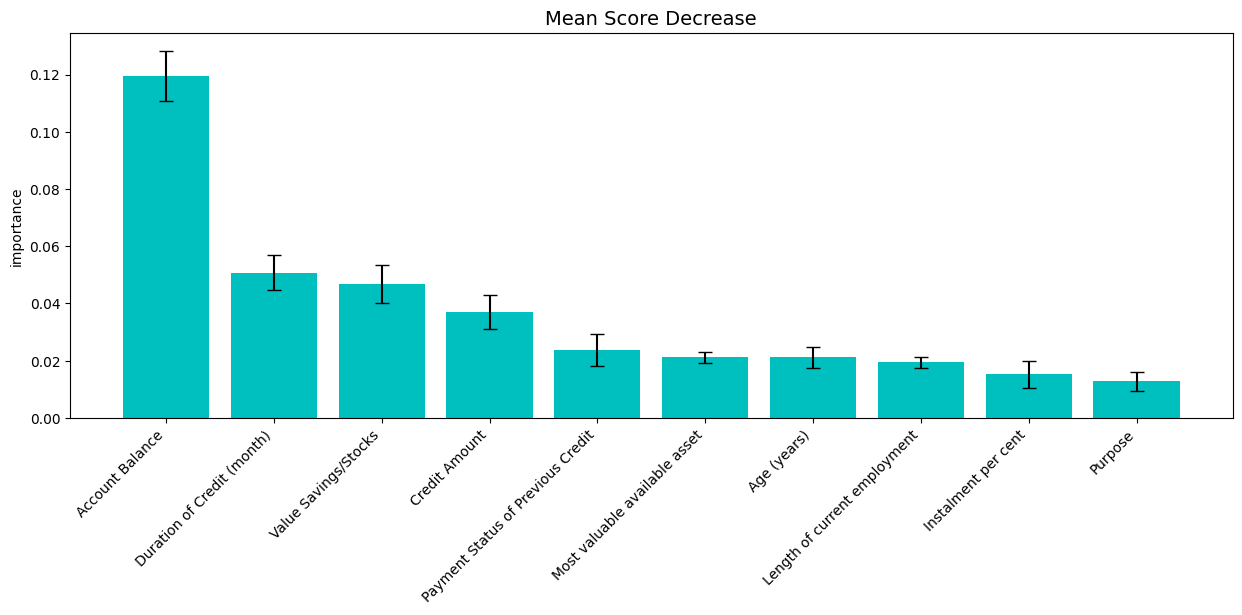

In [183]:
from jcopml.feature_importance import mean_loss_decrease, mean_score_decrease
model = rf
print(f"\nTop 10 Mean Score Decrease Feature Importance:")
df_imp = mean_score_decrease(X_train, y_train, model, plot=True, topk=10)

# Phase 2

In [184]:
df.describe().columns

Index(['Creditability', 'Account Balance', 'Duration of Credit (month)',
       'Payment Status of Previous Credit', 'Purpose', 'Credit Amount',
       'Value Savings/Stocks', 'Length of current employment',
       'Instalment per cent', 'Sex & Marital Status', 'Guarantors',
       'Duration in Current address', 'Most valuable available asset',
       'Age (years)', 'Concurrent Credits', 'Type of apartment',
       'No of Credits at this Bank', 'Occupation', 'No of dependents',
       'Telephone', 'Foreign Worker'],
      dtype='object')

In [185]:
X = df[['Account Balance', 'Duration of Credit (month)', 'Value Savings/Stocks', 'Credit Amount']]
y = df['Creditability']

In [235]:
X.to_csv('../data/processed/feature.csv', index=False)
y.to_csv('../data/processed/label.csv', index=False)
X.tail()

,Account Balance,Duration of Credit (month),Value Savings/Stocks,Credit Amount
995,1,24,1,1987
996,1,24,1,2303
997,4,21,5,12680
998,2,12,5,6468
999,1,30,5,6350


In [187]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [188]:
rf = RandomForestClassifier(
    n_estimators=200,          # lebih banyak pohon → lebih stabil
    max_depth=10,              # batasi kedalaman → cegah overfit
    min_samples_split=10,      # butuh min 10 sampel untuk split
    min_samples_leaf=4,        # tiap leaf min 4 sampel → lebih robust
    max_features='sqrt',       # standar untuk klasifikasi
    max_samples=0.8,           # bagging 80% data per pohon
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [189]:
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# Classification report
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Bad (0)', 'Good (1)']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(cm)
print(f"TN: {cm[0,0]}, FP: {cm[0,1]}")
print(f"FN: {cm[1,0]}, TP: {cm[1,1]}")

# ROC-AUC
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC Score: {auc_score:.4f}")

# Cross-validation
print(f"\nCross-Validation (5-fold):")
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print(f"Accuracy scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
# Feature importance
print(f"\nTop 10 Feature Importance:")
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance.head(10))


Accuracy: 0.7200

Classification Report:
              precision    recall  f1-score   support

     Bad (0)       0.53      0.58      0.56        60
    Good (1)       0.81      0.78      0.80       140

    accuracy                           0.72       200
   macro avg       0.67      0.68      0.68       200
weighted avg       0.73      0.72      0.72       200


Confusion Matrix:
[[ 35  25]
 [ 31 109]]
TN: 35, FP: 25
FN: 31, TP: 109

ROC-AUC Score: 0.7487

Cross-Validation (5-fold):
Accuracy scores: [0.71  0.725 0.765 0.77  0.575]
Mean CV Accuracy: 0.7090 (+/- 0.0708)

Top 10 Feature Importance:
                      feature  importance
3               Credit Amount    0.350916
0             Account Balance    0.281985
1  Duration of Credit (month)    0.246680
2        Value Savings/Stocks    0.120420


# Deployment

In [193]:
import pickle

with open('../models/rf_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

In [194]:
with open('../models/rf_model.pkl', 'rb') as f:
    rf_pickle = pickle.load(f)

In [241]:
new_data = [[3, 10, 2, 1300]]
new_data = pd.DataFrame(new_data, columns=X.columns)
rf_pickle.predict(new_data)

array([1])